
📊 총 탐색량 시각화 (피처 4개)


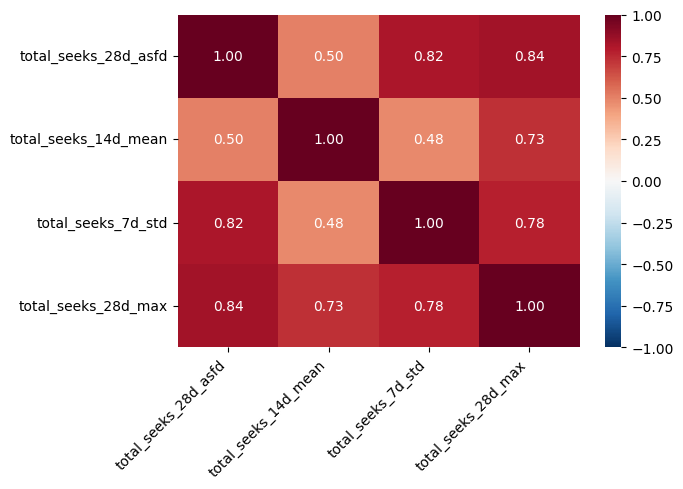


📊 총 읽기량 시각화 (피처 4개)


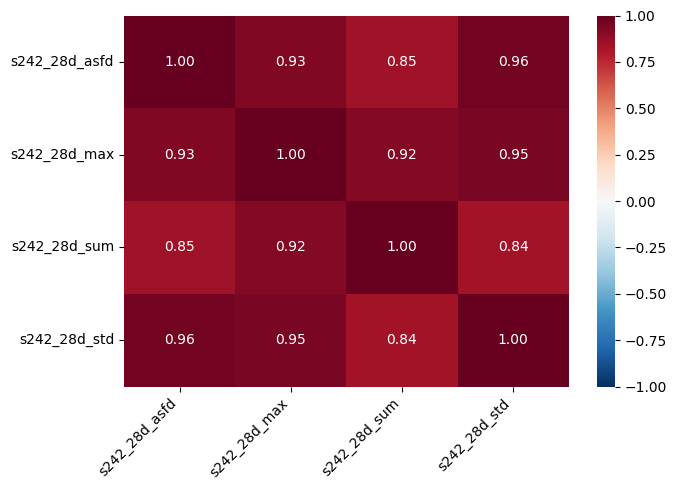

[!] 고중복 탐지 (|rho| > 0.9):
  - s242_28d_asfd <-> s242_28d_std : 0.9622
  - s242_28d_max <-> s242_28d_std : 0.9510
  - s242_28d_asfd <-> s242_28d_max : 0.9266
  - s242_28d_max <-> s242_28d_sum : 0.9193

📊 총 기록량 시각화 (피처 4개)


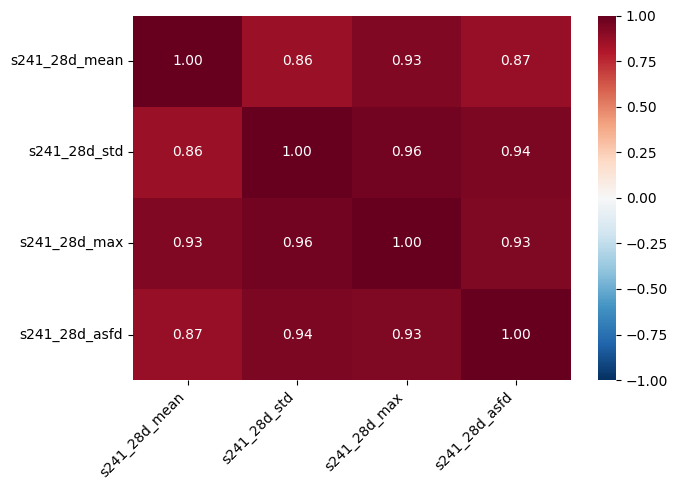

[!] 고중복 탐지 (|rho| > 0.9):
  - s241_28d_std <-> s241_28d_max : 0.9612
  - s241_28d_std <-> s241_28d_asfd : 0.9386
  - s241_28d_max <-> s241_28d_asfd : 0.9297
  - s241_28d_mean <-> s241_28d_max : 0.9291

📊 온도 수준 시각화 (피처 2개)


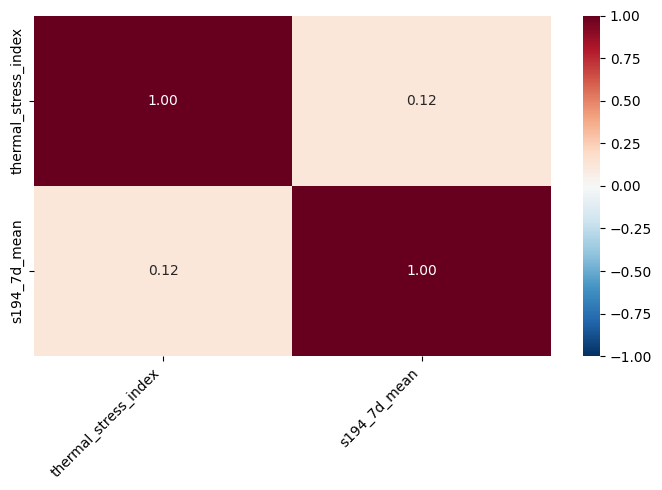


############################################################
📌 모든 그룹의 텍스트 상관행렬 리스트
############################################################

[총 탐색량 Spearman Matrix]
                      total_seeks_28d_asfd  total_seeks_14d_mean  total_seeks_7d_std  total_seeks_28d_max
total_seeks_28d_asfd                 1.000                 0.501               0.818                0.839
total_seeks_14d_mean                 0.501                 1.000               0.483                0.731
total_seeks_7d_std                   0.818                 0.483               1.000                0.775
total_seeks_28d_max                  0.839                 0.731               0.775                1.000
------------------------------------------------------------

[총 읽기량 Spearman Matrix]
               s242_28d_asfd  s242_28d_max  s242_28d_sum  s242_28d_std
s242_28d_asfd          1.000         0.927         0.850         0.962
s242_28d_max           0.927         1.000         0.919         0.951
s

In [3]:
import warnings
import logging
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 설정
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)

# 2. 데이터 로드
path = r'C:\Workspace\06_ML_projdect\26_1_COIN\data\rfe_sample_data\rfe_train.parquet'
con = duckdb.connect()
df = con.execute(f"SELECT * FROM read_parquet('{path}')").df()

# 3. 피처 그룹 정의
feature_groups = {
    "총 탐색량": [
        ("total_seeks_7d_mean", "total_seeks_7d_sum"), ("total_seeks_14d_mean", "total_seeks_14d_sum"),
        ("total_seeks_7d_cid", "total_seeks_7d_asfd"), ("total_seeks_14d_cid", "total_seeks_14d_asfd"),
        ("total_seeks_28d_mean", "total_seeks_28d_sum"), ("total_seeks_28d_cid", "total_seeks_28d_asfd"),
        ("total_seeks_7d_cid", "total_seeks_7d_std"), ("total_seeks_14d_cid", "total_seeks_14d_std"),
        ("total_seeks_14d_ewma", "total_seeks_7d_ewma"), ("total_seeks_28d_cid", "total_seeks_28d_std"),
        ("total_seeks_28d_mean", "total_seeks_14d_ewma"), ("total_seeks_7d_asfd", "total_seeks_7d_std"),
        ("total_seeks_14d_mean", "total_seeks_7d_mean"), ("total_seeks_28d_ewma", "total_seeks_14d_ewma"),
        ("total_seeks_14d_sum", "total_seeks_7d_sum"), ("total_seeks_14d_mean", "total_seeks_7d_sum"),
        ("total_seeks_7d_ewma", "total_seeks_7d_mean"), ("total_seeks_14d_asfd", "total_seeks_14d_std"),
        ("total_seeks_14d_mean", "total_seeks_7d_ewma"), ("total_seeks_14d_sum", "total_seeks_7d_mean"),
        ("total_seeks_28d_asfd", "total_seeks_14d_asfd"), ("total_seeks_28d_max", "total_seeks_14d_max"),
        ("total_seeks_28d_zscore", "total_seeks_14d_zscore"), ("total_seeks_28d_sum", "total_seeks_14d_ewma"),
        ("total_seeks_14d_sum", "total_seeks_7d_ewma"), ("total_seeks_28d_mean", "total_seeks_14d_mean"),
        ("total_seeks_28d_asfd", "total_seeks_28d_std"), ("total_seeks_28d_cid", "total_seeks_14d_cid"),
        ("total_seeks_28d_sum", "total_seeks_14d_sum"), ("total_seeks_14d_max", "total_seeks_7d_max"),
        ("total_seeks_14d_asfd", "total_seeks_7d_asfd"), ("total_seeks_28d_mean", "total_seeks_14d_sum"),
        ("total_seeks_28d_cid", "total_seeks_14d_asfd"), ("total_seeks_14d_zscore", "total_seeks_7d_zscore"),
        ("total_seeks_14d_ewma", "total_seeks_14d_mean"), ("total_seeks_28d_asfd", "total_seeks_14d_cid"),
        ("total_seeks_14d_cid", "total_seeks_7d_cid"), ("total_seeks_14d_asfd", "total_seeks_7d_cid"),
        ("total_seeks_28d_sum", "total_seeks_14d_mean"), ("total_seeks_14d_ewma", "total_seeks_14d_sum"),
        ("total_seeks_14d_cid", "total_seeks_7d_asfd"), ("total_seeks_28d_mean", "total_seeks_7d_ewma")
    ],
    "총 읽기량": [
        ("total_reads_28d_mean", "total_reads_28d_sum"), ("s242_28d_mean", "s242_28d_sum"),
        ("s242_28d_cid", "s242_28d_asfd"), ("s242_28d_ewma", "s242_28d_mean"),
        ("s242_28d_cid", "s242_28d_std"), ("s242_28d_ewma", "s242_28d_sum"),
        ("total_reads_28d_cid", "total_reads_28d_asfd"), ("s242_28d_asfd", "s242_28d_std"),
        ("s242_28d_std", "s242_28d_max"), ("s242_28d_cid", "s242_28d_max"),
        ("s242_28d_asfd", "s242_28d_max"), ("total_reads_28d_cid", "total_reads_28d_std"),
        ("s242_28d_mean", "s242_28d_max"), ("s242_28d_sum", "s242_28d_max"),
        ("s242_28d_ewma", "s242_28d_max")
    ],
    "총 기록량": [
        ("s241_28d_ewma", "s241_28d_mean"), ("s241_28d_mean", "s241_28d_sum"),
        ("s241_28d_cid", "s241_28d_asfd"), ("s241_28d_ewma", "s241_28d_sum"),
        ("s241_28d_std", "s241_28d_max"), ("s241_28d_cid", "s241_28d_std"),
        ("s241_28d_cid", "s241_28d_max"), ("s241_28d_asfd", "s241_28d_std"),
        ("s241_28d_mean", "s241_28d_max"), ("s241_28d_asfd", "s241_28d_max"),
        ("s241_28d_sum", "s241_28d_max"), ("s241_28d_ewma", "s241_28d_max")
    ],
    "기본 I/O 이상": [("timeout_severity_ratio", "timeout_read_density")],
    "열 스트레스": [
        ("s190_28d_ewma", "s190_28d_mean"), ("s190_28d_ewma", "s190_14d_mean"),
        ("s190_14d_mean", "s190_7d_mean"), ("s190_28d_mean", "s190_14d_mean"),
        ("s190_28d_ewma", "s190_7d_mean"), ("s190_28d_mean", "s190_7d_mean")
    ],
    "온도 수준": [
        ("s194_14d_mean", "s194_7d_mean"), ("s194_28d_mean", "s194_14d_mean"),
        ("s194_28d_mean", "s194_7d_mean"), ("thermal_stress_index", "s194_over40_7d_count")
    ],
    "직접 손상 발생": [("s198_damaged", "s197_damaged")]
}

# 상관행렬 텍스트 저장용 딕셔너리
text_matrices = {}
threshold = 0.90 

# --- [Main Loop 수정본] ---
for group_name, pairs in feature_groups.items():
    try:
        # 1. 튜플 리스트를 단일 컬럼 리스트로 평탄화(Flatten)
        all_potential_cols = []
        for p in pairs:
            if isinstance(p, tuple):
                all_potential_cols.extend(list(p))
            else:
                all_potential_cols.append(p)
        
        # 중복 제거
        unique_cols = list(set(all_potential_cols))
        
        # 2. 실제 데이터프레임에 존재하는 컬럼만 필터링
        valid_cols = [c for c in unique_cols if c in df.columns]
        
        if len(valid_cols) < 2:
            # print(f"⚠️ {group_name}: 유효한 피처가 2개 미만입니다.")
            continue
        
        # 3. 데이터 추출 및 전처리
        sub_df = df[valid_cols].apply(pd.to_numeric, errors='coerce')
        # 상수 컬럼 제거 및 결측치 채우기
        sub_df = sub_df.loc[:, sub_df.nunique() > 1]
        
        if sub_df.shape[1] < 2: continue

        sub_df = sub_df.fillna(sub_df.median())

        # 4. Spearman 상관계수 계산
        corr_matrix = sub_df.corr(method='spearman')
        text_matrices[group_name] = corr_matrix 

        print(f"\n" + "="*50)
        print(f"📊 {group_name} 시각화 (피처 {len(sub_df.columns)}개)")

        # 5. 시각화
        n = len(sub_df.columns)
        figsize = (max(7, min(18, n * 0.9)), max(5, min(14, n * 0.7)))
        plt.figure(figsize=figsize)
        sns.heatmap(corr_matrix, annot=(n <= 20), fmt=".2f", cmap='RdBu_r', vmin=-1, vmax=1, center=0)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # 6. 고중복 탐지
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        redundant = upper.stack().loc[lambda x: abs(x) > threshold].sort_values(ascending=False)
        if not redundant.empty:
            print(f"[!] 고중복 탐지 (|rho| > {threshold}):")
            for (f1, f2), val in redundant.items():
                print(f"  - {f1} <-> {f2} : {val:.4f}")

    except Exception as e:
        print(f"[Error] {group_name}: {e}")


# --- [Final Output: 텍스트 상관행렬 모음] ---
print("\n" + "#" * 60)
print("📌 모든 그룹의 텍스트 상관행렬 리스트")
print("#" * 60)

for group_name, matrix in text_matrices.items():
    print(f"\n[{group_name} Spearman Matrix]")
    # 소수점 3자리까지 깔끔하게 출력
    print(matrix.round(3).to_string())
    print("-" * 60)

con.close()
